# Skrining Anemia Non-Invasif: Konjungtiva vs Telapak Tangan vs Kuku
### EfficientNet-B0 + CBAM — Kelompok 4, Deep Learning

**Cara menjalankan:** `Kernel → Restart & Run All`. Training **tidak** diulang secara default (`JALANKAN_TRAINING = False` di bagian 6); notebook memuat checkpoint hasil `scripts/3_train_models.py`. Kode lengkap ada di folder `src/` dan `scripts/`.

## 1. Topik & Research Gap

Anemia didiagnosis lewat kadar hemoglobin (Hb) dari tes darah, yang invasif dan butuh laboratorium. Secara klinis, anemia terlihat sebagai kepucatan (pallor) pada **konjungtiva mata**, **telapak tangan**, dan **kuku**. Kami melatih model deep learning untuk mendeteksi anemia dari foto ketiga area tersebut, lalu membandingkan mana yang paling informatif.

**Research gap.**
- Sebagian besar studi skrining anemia berbasis citra hanya memakai **satu modalitas** dan satu dataset, sehingga hasil antar-modalitas sulit dibandingkan secara adil (arsitektur, preprocessing, dan protokol evaluasi berbeda).
- Dataset telapak tangan dan kuku berisi **augmentasi bawaan** (710 foto → 4.260 citra). Jika split dilakukan per citra, salinan dari pasien yang sama bisa masuk train dan test (kebocoran data) sehingga akurasi terlihat terlalu tinggi.
- Model yang ditujukan untuk skrining di lapangan perlu **ringan** (bisa jalan di perangkat sederhana), tetapi tetap dapat dijelaskan (explainable).

**Kontribusi notebook ini.**
1. Perbandingan 3 modalitas dengan **arsitektur, preprocessing, dan hyperparameter yang sama** (EfficientNet-B0 + CBAM, LR 3e-5).
2. Split **per pasien/subjek** (bukan per citra) + cek kebocoran.
3. Konjungtiva memakai **gabungan 2 dataset** (CP-AnemiC + Eyes-Defy) dan diuji **cross-domain** pada subset Eyes-Defy yang tidak dipakai saat training.
4. Interpretasi dengan **Grad-CAM** dan uji statistik fitur warna.

### Setup

In [1]:
import sys, os, io, time, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True   # sama seperti src/data/dataset.py: PNG terpotong tetap dibaca
import cv2
from scipy.stats import mannwhitneyu
warnings.filterwarnings("ignore")

ROOT = Path.home() / "DeepLearning_Anemia"
sys.path.insert(0, str(ROOT)); os.chdir(ROOT)
from src.config import SPLITS_DIR, CHECKPOINTS_DIR, LOGS_DIR

FIG = ROOT / "results" / "figures" / "eda"; FIG.mkdir(parents=True, exist_ok=True)
TAB = ROOT / "results" / "tables";         TAB.mkdir(parents=True, exist_ok=True)

# Konjungtiva = gabungan CP-AnemiC + Eyes-Defy (928 citra) kalau split gabungannya sudah dibuat
KONJ = "conjunctiva" if (SPLITS_DIR / "conjunctiva_merged_splits.csv").exists() else "cp_anemic"
SPLIT_FILE = {"conjunctiva": "conjunctiva_merged_splits.csv"}
MOD = {KONJ: "Konjungtiva", "palm": "Telapak Tangan", "fingernail": "Kuku"}

MODALITAS_DIPAKAI = list(MOD)
MOD = {m: n for m, n in MOD.items() if m in MODALITAS_DIPAKAI}
SUMBER = {"cp_anemic": "CP-AnemiC (anak, Ghana)", "eyes_defy": "Eyes-Defy (dewasa, Italia & India)"}
LBL = {0: "Non-anemia", 1: "Anemia"}
PAL = {"Anemia": "#E45756", "Non-anemia": "#4C78A8"}
HUE = ["Anemia", "Non-anemia"]
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=200); plt.show()

dfs = {}
for m in MOD:
    d = pd.read_csv(SPLITS_DIR / SPLIT_FILE.get(m, f"{m}_splits.csv"))
    d["label"] = d["who_anemic"].astype(int).map(LBL)
    if "subject_id" not in d: d["subject_id"] = d["patient_id"].astype(str)
    dfs[m] = d
print("Konjungtiva memakai:", "GABUNGAN CP-AnemiC + Eyes-Defy" if KONJ == "conjunctiva" else "CP-AnemiC saja (split gabungan belum dibuat)")
print({MOD[m]: len(d) for m, d in dfs.items()})

def bisa_dibuka(p):
    try:
        with Image.open(p) as im: im.convert("RGB")
        return True
    except Exception:
        return False

for m in dfs:
    ok = dfs[m]["image_path"].map(bisa_dibuka)
    if (~ok).sum():
        print(f"{MOD[m]}: {(~ok).sum()} citra rusak dilewati")
    dfs[m] = dfs[m][ok].reset_index(drop=True)

Konjungtiva memakai: GABUNGAN CP-AnemiC + Eyes-Defy
{'Konjungtiva': 927, 'Telapak Tangan': 4260, 'Kuku': 4260}


## 2. Eksplorasi Dataset (EDA)

| Modalitas | Sumber dataset | Isi |
|---|---|---|
| Konjungtiva | CP-AnemiC (anak, Ghana) + Eyes-Defy (dewasa, Italia & India) | ROI konjungtiva palpebra + nilai Hb |
| Telapak tangan | Dataset palm (Mendeley) | ROI telapak, 710 foto → 4.260 citra (augmentasi penyusun) |
| Kuku | Dataset fingernail (Mendeley) | ROI kuku, 710 foto → 4.260 citra (augmentasi penyusun) |

Label: anemia vs non-anemia berdasarkan batas Hb WHO.

### 2.1 Ukuran dataset & distribusi kelas

,Modalitas,Total citra,Citra asli (tanpa sufiks augmentasi),Grup subjek (unit split),Citra per grup subjek,Anemia,Non-anemia,% Anemia
0,Konjungtiva,927,927,927,1.00,515,412,55.6
1,Telapak Tangan,4260,526,475,8.97,2562,1698,60.1
2,Kuku,4260,556,475,8.97,2565,1695,60.2


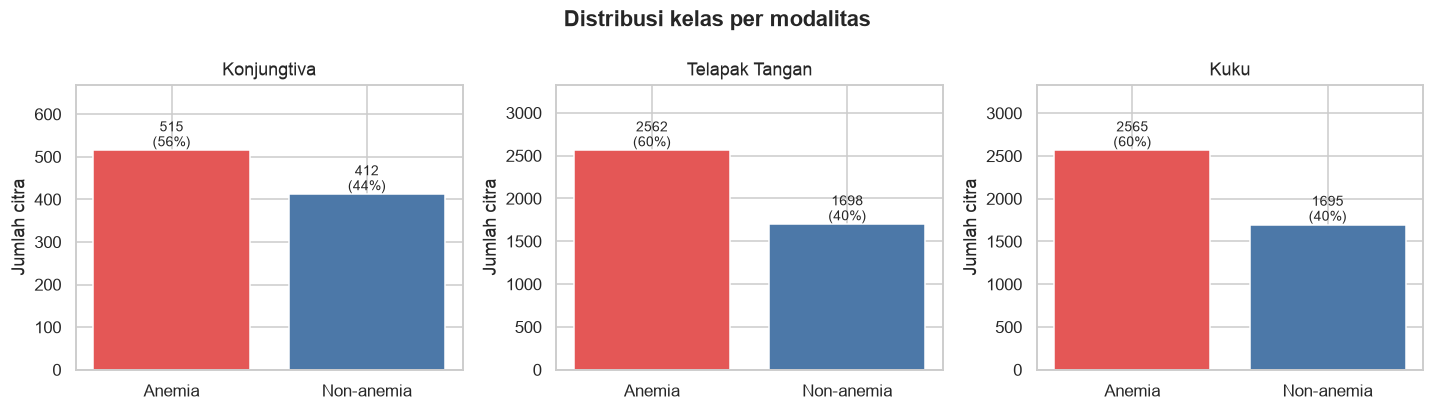

label,Anemia,Non-anemia,Total
source_dataset,,,
"CP-AnemiC (anak, Ghana)",424,286,710
"Eyes-Defy (dewasa, Italia & India)",91,126,217
Total,515,412,927


In [2]:
rows = []
for m, d in dfs.items():
    ic = d["label"].value_counts()
    tanpa_sufiks = (~d["filename"].str.contains(r"\(\d+\)")).sum() if "filename" in d else len(d)
    rows.append({"Modalitas": MOD[m], "Total citra": len(d),
                 "Citra asli (tanpa sufiks augmentasi)": tanpa_sufiks,
                 "Grup subjek (unit split)": d["subject_id"].nunique(),
                 "Citra per grup subjek": round(len(d) / d["subject_id"].nunique(), 2),
                 "Anemia": ic.get("Anemia", 0), "Non-anemia": ic.get("Non-anemia", 0),
                 "% Anemia": round(100 * ic.get("Anemia", 0) / len(d), 1)})
ringkas = pd.DataFrame(rows); ringkas.to_csv(TAB / "eda_ringkasan_dataset.csv", index=False)
display(ringkas)

fig, ax = plt.subplots(1, len(MOD), figsize=(4.4 * len(MOD), 3.8), squeeze=False); ax = ax[0]
for a, (m, d) in zip(ax, dfs.items()):
    c = d["label"].value_counts().reindex(HUE)
    a.bar(c.index, c.values, color=[PAL[k] for k in c.index])
    for i, v in enumerate(c.values):
        a.text(i, v, f"{v}\n({v/len(d):.0%})", ha="center", va="bottom", fontsize=9)
    a.set_title(MOD[m]); a.set_ylabel("Jumlah citra"); a.set_ylim(0, c.max() * 1.3)
fig.suptitle("Distribusi kelas per modalitas", fontweight="bold"); fig.tight_layout(); save(fig, "01_distribusi_kelas")

if KONJ in dfs and "source_dataset" in dfs[KONJ]:
    src = pd.crosstab(dfs[KONJ]["source_dataset"].map(SUMBER), dfs[KONJ]["label"], margins=True, margins_name="Total")
    src.to_csv(TAB / "eda_konjungtiva_per_sumber.csv"); display(src)

### 2.2 Pembagian train / val / test & cek kebocoran data

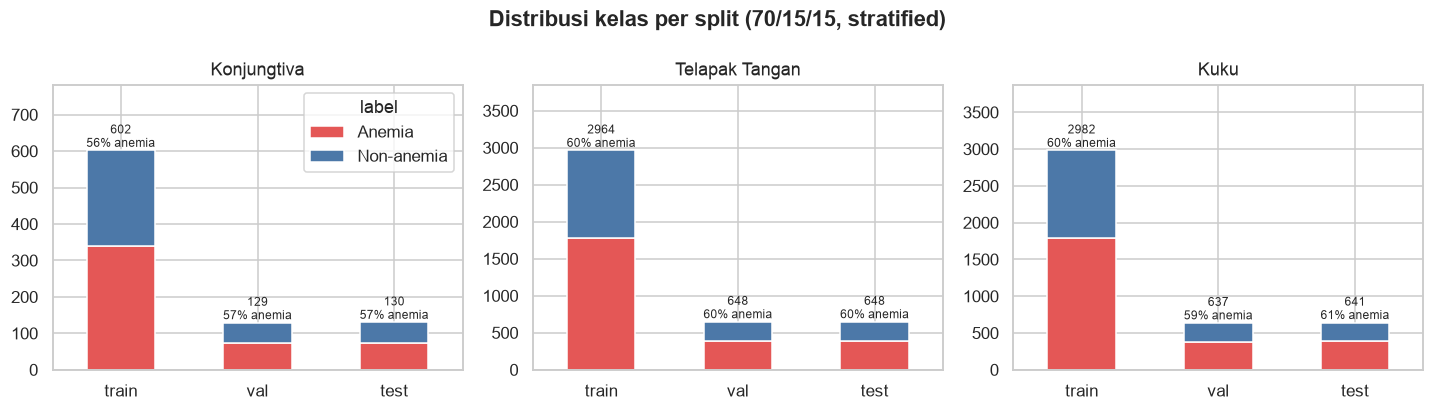

Konjungtiva     grup subjek yang muncul di >1 split: 0
Telapak Tangan  grup subjek yang muncul di >1 split: 0
Kuku            grup subjek yang muncul di >1 split: 0


In [3]:
ORDER = ["train", "val", "test"]; rows = []
fig, ax = plt.subplots(1, len(MOD), figsize=(4.4 * len(MOD), 3.8), squeeze=False); ax = ax[0]
for a, (m, d) in zip(ax, dfs.items()):
    ct = pd.crosstab(d["split"], d["label"]).reindex(ORDER)[HUE]
    ct.plot(kind="bar", stacked=True, ax=a, color=[PAL[h] for h in HUE], legend=(a is ax[0]), rot=0)
    for i, s in enumerate(ORDER):
        tot = int(ct.loc[s].sum())
        a.text(i, tot, f"{tot}\n{ct.loc[s,'Anemia']/tot:.0%} anemia", ha="center", va="bottom", fontsize=8)
        rows.append({"Modalitas": MOD[m], "Split": s, "Anemia": int(ct.loc[s, "Anemia"]),
                     "Non-anemia": int(ct.loc[s, "Non-anemia"]), "Total": tot})
    a.set_title(MOD[m]); a.set_xlabel(""); a.set_ylim(0, ct.sum(axis=1).max() * 1.3)
fig.suptitle("Distribusi kelas per split (70/15/15, stratified)", fontweight="bold"); fig.tight_layout(); save(fig, "02_distribusi_split")
pd.DataFrame(rows).to_csv(TAB / "eda_split.csv", index=False)

for m, d in dfs.items():
    g = {s: set(d.loc[d["split"] == s, "subject_id"]) for s in ORDER}
    bocor = len((g["train"] & g["val"]) | (g["train"] & g["test"]) | (g["val"] & g["test"]))
    print(f"{MOD[m]:15s} grup subjek yang muncul di >1 split: {bocor}")

### 2.3 Augmentasi bawaan dataset (palm & kuku)
Dataset palm dan kuku sudah diaugmentasi oleh penyusunnya (710 → 4.260). Grafik ini menunjukkan berapa citra yang berasal dari satu grup subjek.

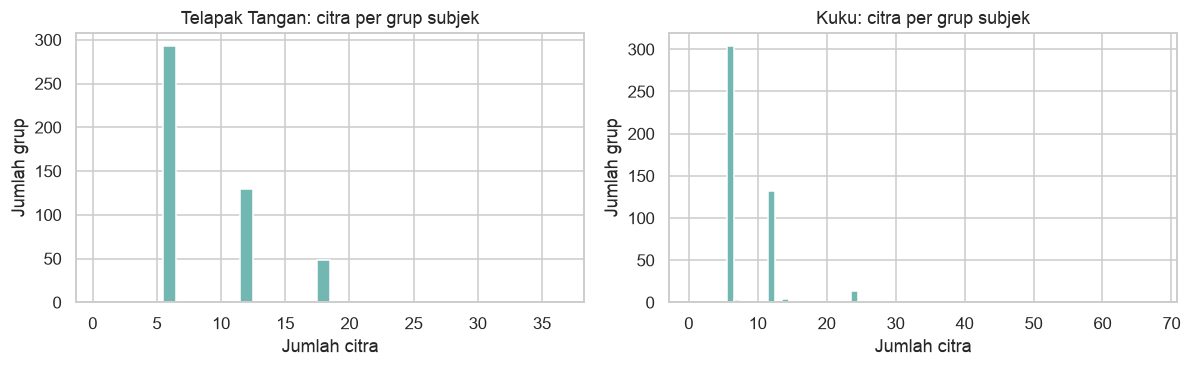

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for a, m in zip(ax, ["palm", "fingernail"]):
    cnt = dfs[m].groupby("subject_id").size()
    a.hist(cnt, bins=range(1, cnt.max() + 2), color="#72B7B2", edgecolor="white", align="left")
    a.set_title(f"{MOD[m]}: citra per grup subjek"); a.set_xlabel("Jumlah citra"); a.set_ylabel("Jumlah grup")
fig.tight_layout(); save(fig, "03_citra_per_subjek")

### 2.4 Resolusi & format citra

In [5]:
res = []
for m, d in dfs.items():
    for p in d.sample(min(300, len(d)), random_state=42)["image_path"]:
        with Image.open(p) as im: res.append({"Modalitas": MOD[m], "w": im.size[0], "h": im.size[1], "mode": im.mode})
res = pd.DataFrame(res)
resolusi = res.groupby("Modalitas").agg(
    lebar_min=("w", "min"), lebar_median=("w", "median"), lebar_max=("w", "max"),
    tinggi_min=("h", "min"), tinggi_median=("h", "median"), tinggi_max=("h", "max"),
    mode_warna=("mode", lambda x: ", ".join(sorted(set(x)))))
resolusi.to_csv(TAB / "eda_resolusi.csv"); display(resolusi)
print("Semua citra di-resize ke 224x224 sebelum masuk model.")

,lebar_min,lebar_median,lebar_max,tinggi_min,tinggi_median,tinggi_max,mode_warna
Modalitas,,,,,,,
Konjungtiva,79,269.0,800,34,105.0,1067,RGBA
Kuku,25,75.0,171,21,67.0,216,RGBA
Telapak Tangan,73,183.5,751,73,186.0,583,RGBA


Semua citra di-resize ke 224x224 sebelum masuk model.


### 2.5 Contoh citra

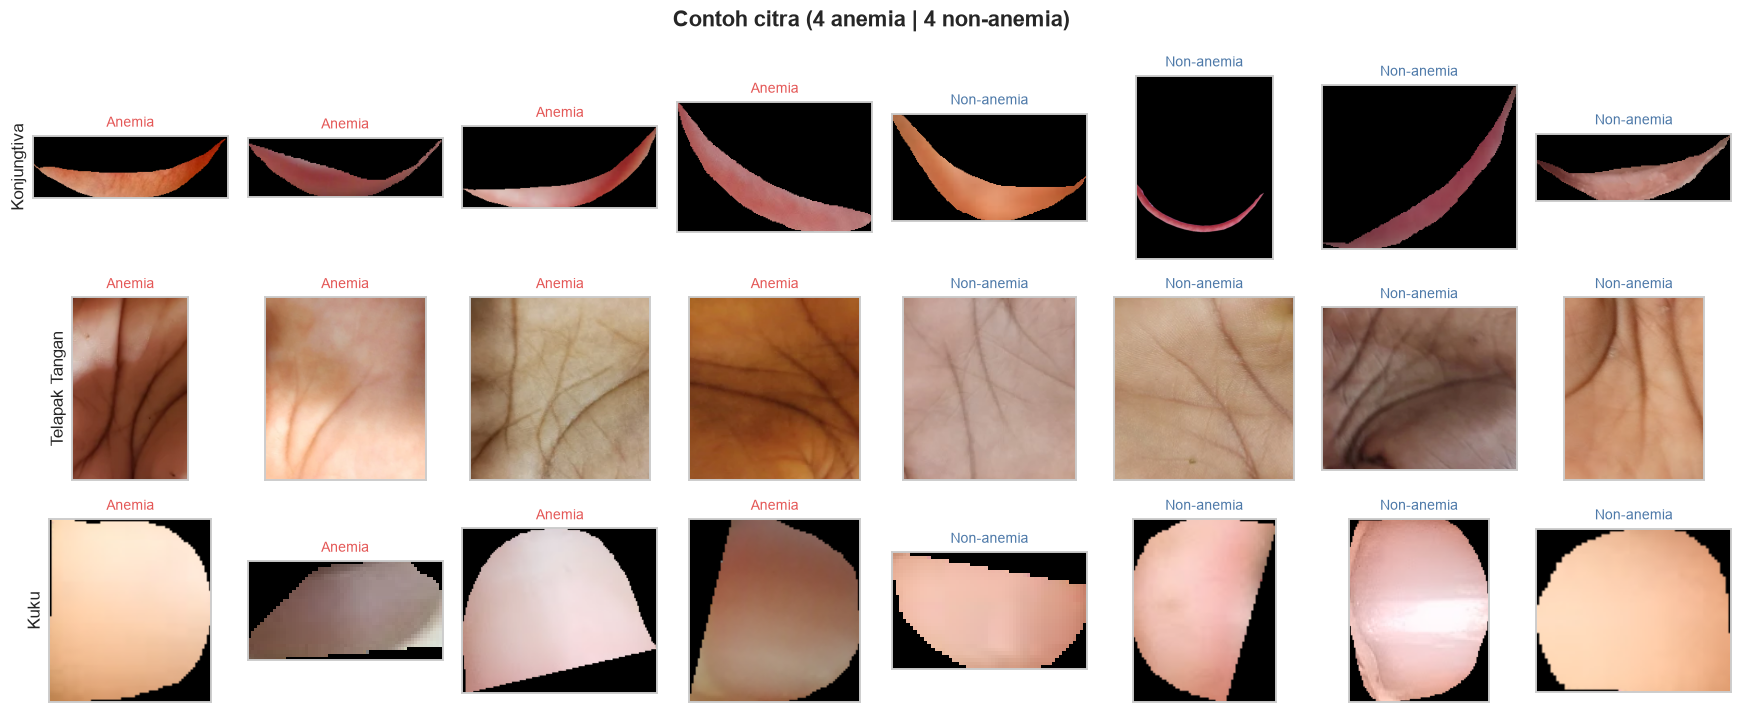

In [6]:
fig, ax = plt.subplots(len(MOD), 8, figsize=(16, 2.2 * len(MOD)), squeeze=False)
for r, (m, d) in enumerate(dfs.items()):
    u = d.drop_duplicates("subject_id")
    picks = pd.concat([u[u.who_anemic == 1].sample(4, random_state=1), u[u.who_anemic == 0].sample(4, random_state=1)])
    for c, (_, row) in enumerate(picks.iterrows()):
        a = ax[r, c]; a.imshow(Image.open(row.image_path).convert("RGB")); a.grid(False)
        a.set_xticks([]); a.set_yticks([]); a.set_title(row.label, fontsize=9, color=PAL[row.label])
    ax[r, 0].set_ylabel(MOD[m], fontsize=11)
fig.suptitle("Contoh citra (4 anemia | 4 non-anemia)", fontweight="bold"); fig.tight_layout(); save(fig, "04_contoh_citra")

### 2.6 Analisis warna: apakah kepucatan terlihat?
Satu citra per grup subjek (supaya hasil augmentasi tidak dihitung berulang). Piksel gelap (latar belakang) dibuang. Uji Mann-Whitney U: p < 0,05 artinya warna anemia vs non-anemia berbeda signifikan.

,Modalitas,Fitur,Median anemia,Median non-anemia,p-value,Beda signifikan?
0,Konjungtiva,a* CIELAB (kemerahan),26.018,28.269,0.000086,Ya
1,Konjungtiva,Erythema index,19.398,20.560,0.011000,Ya
2,Konjungtiva,Saturasi HSV,0.437,0.434,0.230000,Tidak
3,Konjungtiva,Kecerahan HSV,0.726,0.727,0.490000,Tidak
4,Telapak Tangan,a* CIELAB (kemerahan),13.288,15.316,0.000001,Ya
5,Telapak Tangan,Erythema index,11.249,13.517,0.000170,Ya
6,Telapak Tangan,Saturasi HSV,0.386,0.398,0.033000,Ya
7,Telapak Tangan,Kecerahan HSV,0.700,0.712,0.170000,Tidak
8,Kuku,a* CIELAB (kemerahan),12.547,11.661,0.730000,Tidak
9,Kuku,Erythema index,8.927,9.080,0.600000,Tidak


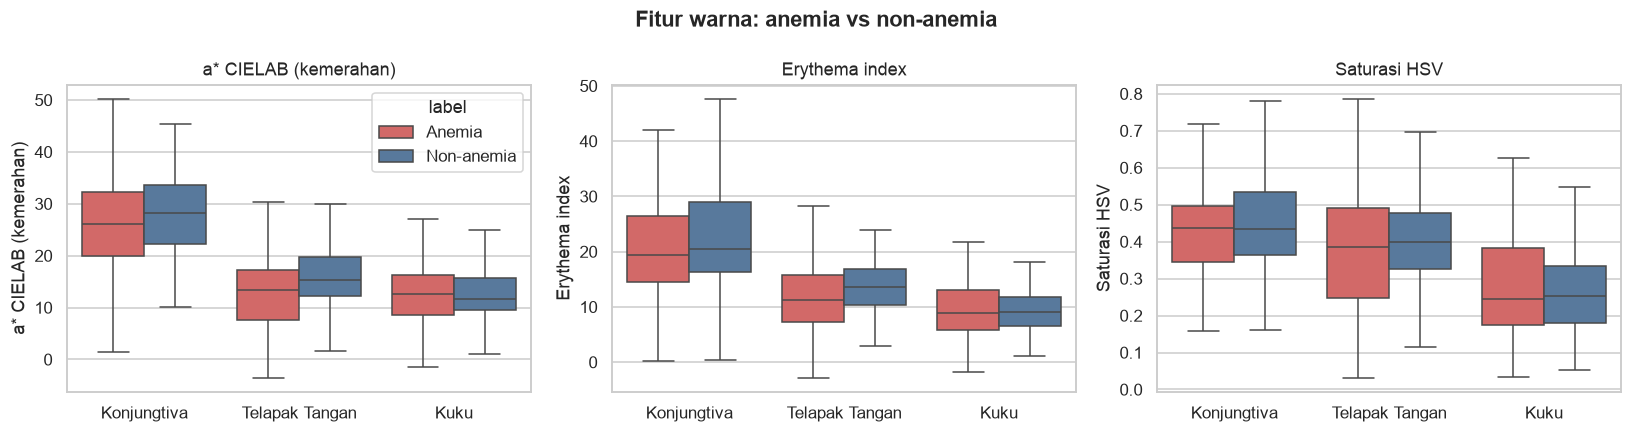

In [7]:
def fitur_warna(p):
    rgb = np.asarray(Image.open(p).convert("RGB").resize((224, 224)))
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV); lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(float)
    mask = hsv[..., 2] > 25
    if mask.sum() < 100: mask = np.ones(mask.shape, bool)
    R, G, B = (rgb[..., i][mask].astype(float).mean() for i in range(3))
    return {"a* CIELAB (kemerahan)": lab[..., 1][mask].mean() - 128,
            "Erythema index": 100 * (np.log10(R + 1) - np.log10(G + 1)),
            "Saturasi HSV": hsv[..., 1][mask].mean() / 255,
            "Kecerahan HSV": hsv[..., 2][mask].mean() / 255}

feat = []
for m, d in dfs.items():
    for _, row in d.drop_duplicates("subject_id").iterrows():
        f = fitur_warna(row.image_path); f.update(Modalitas=MOD[m], label=row.label); feat.append(f)
feat = pd.DataFrame(feat); feat.to_csv(TAB / "eda_fitur_warna.csv", index=False)
FITUR = [c for c in feat.columns if c not in ("Modalitas", "label")]

uji = []
for mm, g in feat.groupby("Modalitas", sort=False):
    for f in FITUR:
        a_, n_ = g.loc[g.label == "Anemia", f], g.loc[g.label == "Non-anemia", f]
        p = mannwhitneyu(a_, n_).pvalue
        uji.append({"Modalitas": mm, "Fitur": f, "Median anemia": round(a_.median(), 3),
                    "Median non-anemia": round(n_.median(), 3), "p-value": float(f"{p:.2g}"),
                    "Beda signifikan?": "Ya" if p < 0.05 else "Tidak"})
uji = pd.DataFrame(uji); uji.to_csv(TAB / "eda_uji_warna.csv", index=False); display(uji)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, f in zip(ax, ["a* CIELAB (kemerahan)", "Erythema index", "Saturasi HSV"]):
    sns.boxplot(data=feat, x="Modalitas", y=f, hue="label", hue_order=HUE, palette=PAL, ax=a, showfliers=False)
    a.set_xlabel(""); a.set_title(f)
    if a is not ax[0]: a.get_legend().remove()
fig.suptitle("Fitur warna: anemia vs non-anemia", fontweight="bold"); fig.tight_layout(); save(fig, "05_fitur_warna")

### 2.7 Data klinis konjungtiva (Hb, keparahan, sumber/usia)
Batas anemia WHO: anak < 11 g/dL (CP-AnemiC), dewasa < 12 (perempuan) / < 13 (laki-laki) g/dL (Eyes-Defy).

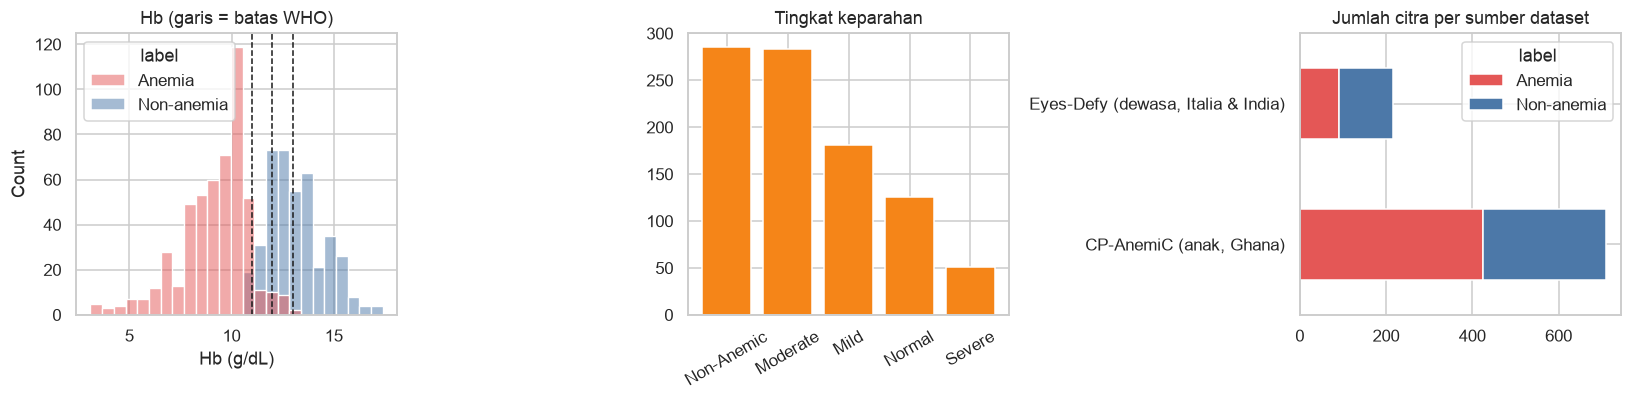

count   mean   std   min    25%    50%    75%  \
source_dataset label                                                       
cp_anemic      Anemia      424.0   8.89  1.61   3.1   8.00   9.20  10.10   
               Non-anemia  286.0  12.53  0.96  11.0  11.90  12.45  13.18   
eyes_defy      Anemia       91.0  10.48  1.43   7.0   9.32  10.60  11.50   
               Non-anemia  126.0  14.47  1.19  12.0  13.70  14.50  15.40   

                             max  
source_dataset label              
cp_anemic      Anemia      10.93  
               Non-anemia  15.00  
eyes_defy      Anemia      12.90  
               Non-anemia  17.40

gender
Male      535
Female    392
Name: Jumlah per gender, dtype: int64

In [8]:
if KONJ not in dfs:
    print("Konjungtiva tidak dipakai di notebook ini, bagian 2.7 dilewati.")
else:
    cp = dfs[KONJ].copy()
    cp["hb"] = pd.to_numeric(cp["hb"], errors="coerce")
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
    sns.histplot(data=cp, x="hb", hue="label", hue_order=HUE, palette=PAL, bins=25, ax=ax[0])
    for t in ([11, 12, 13] if "source_dataset" in cp else [11]): ax[0].axvline(t, ls="--", c="k", lw=1)
    ax[0].set_title("Hb (garis = batas WHO)"); ax[0].set_xlabel("Hb (g/dL)")
    sev = cp["severity"].astype(str).value_counts(); ax[1].bar(sev.index, sev.values, color="#F58518")
    ax[1].set_title("Tingkat keparahan"); ax[1].tick_params(axis="x", rotation=30)
    if "source_dataset" in cp:
        pd.crosstab(cp["source_dataset"].map(SUMBER), cp["label"])[HUE].plot(kind="barh", stacked=True, ax=ax[2], color=[PAL[h] for h in HUE])
        ax[2].set_title("Jumlah citra per sumber dataset"); ax[2].set_ylabel("")
    else:
        cp["age_months"] = pd.to_numeric(cp["age_months"], errors="coerce")
        sns.histplot(data=cp, x="age_months", hue="label", hue_order=HUE, palette=PAL, bins=20, ax=ax[2]); ax[2].set_title("Usia (bulan)")
    fig.tight_layout(); save(fig, "06_konjungtiva_klinis")
    grp = ["source_dataset", "label"] if "source_dataset" in cp else ["label"]
    klinis = cp.groupby(grp)["hb"].describe().round(2); display(klinis); klinis.to_csv(TAB / "eda_konjungtiva_klinis.csv")
    display(cp["gender"].replace({"M": "Male", "F": "Female"}).value_counts().rename("Jumlah per gender"))

**Ringkasan EDA**
- Kelas tidak seimbang (lebih banyak anemia) → dipakai **class-weighted loss** dan metrik F1/AUC, bukan hanya accuracy.
- Palm & kuku punya banyak citra per subjek (augmentasi bawaan) → split **wajib per subjek**.
- Resolusi bervariasi → semua citra di-resize ke 224×224.
- Uji Mann-Whitney menunjukkan apakah warna (kemerahan) berbeda antara anemia dan non-anemia per modalitas; ini memberi gambaran awal modalitas mana yang paling informatif.

## 3. Research Pipeline

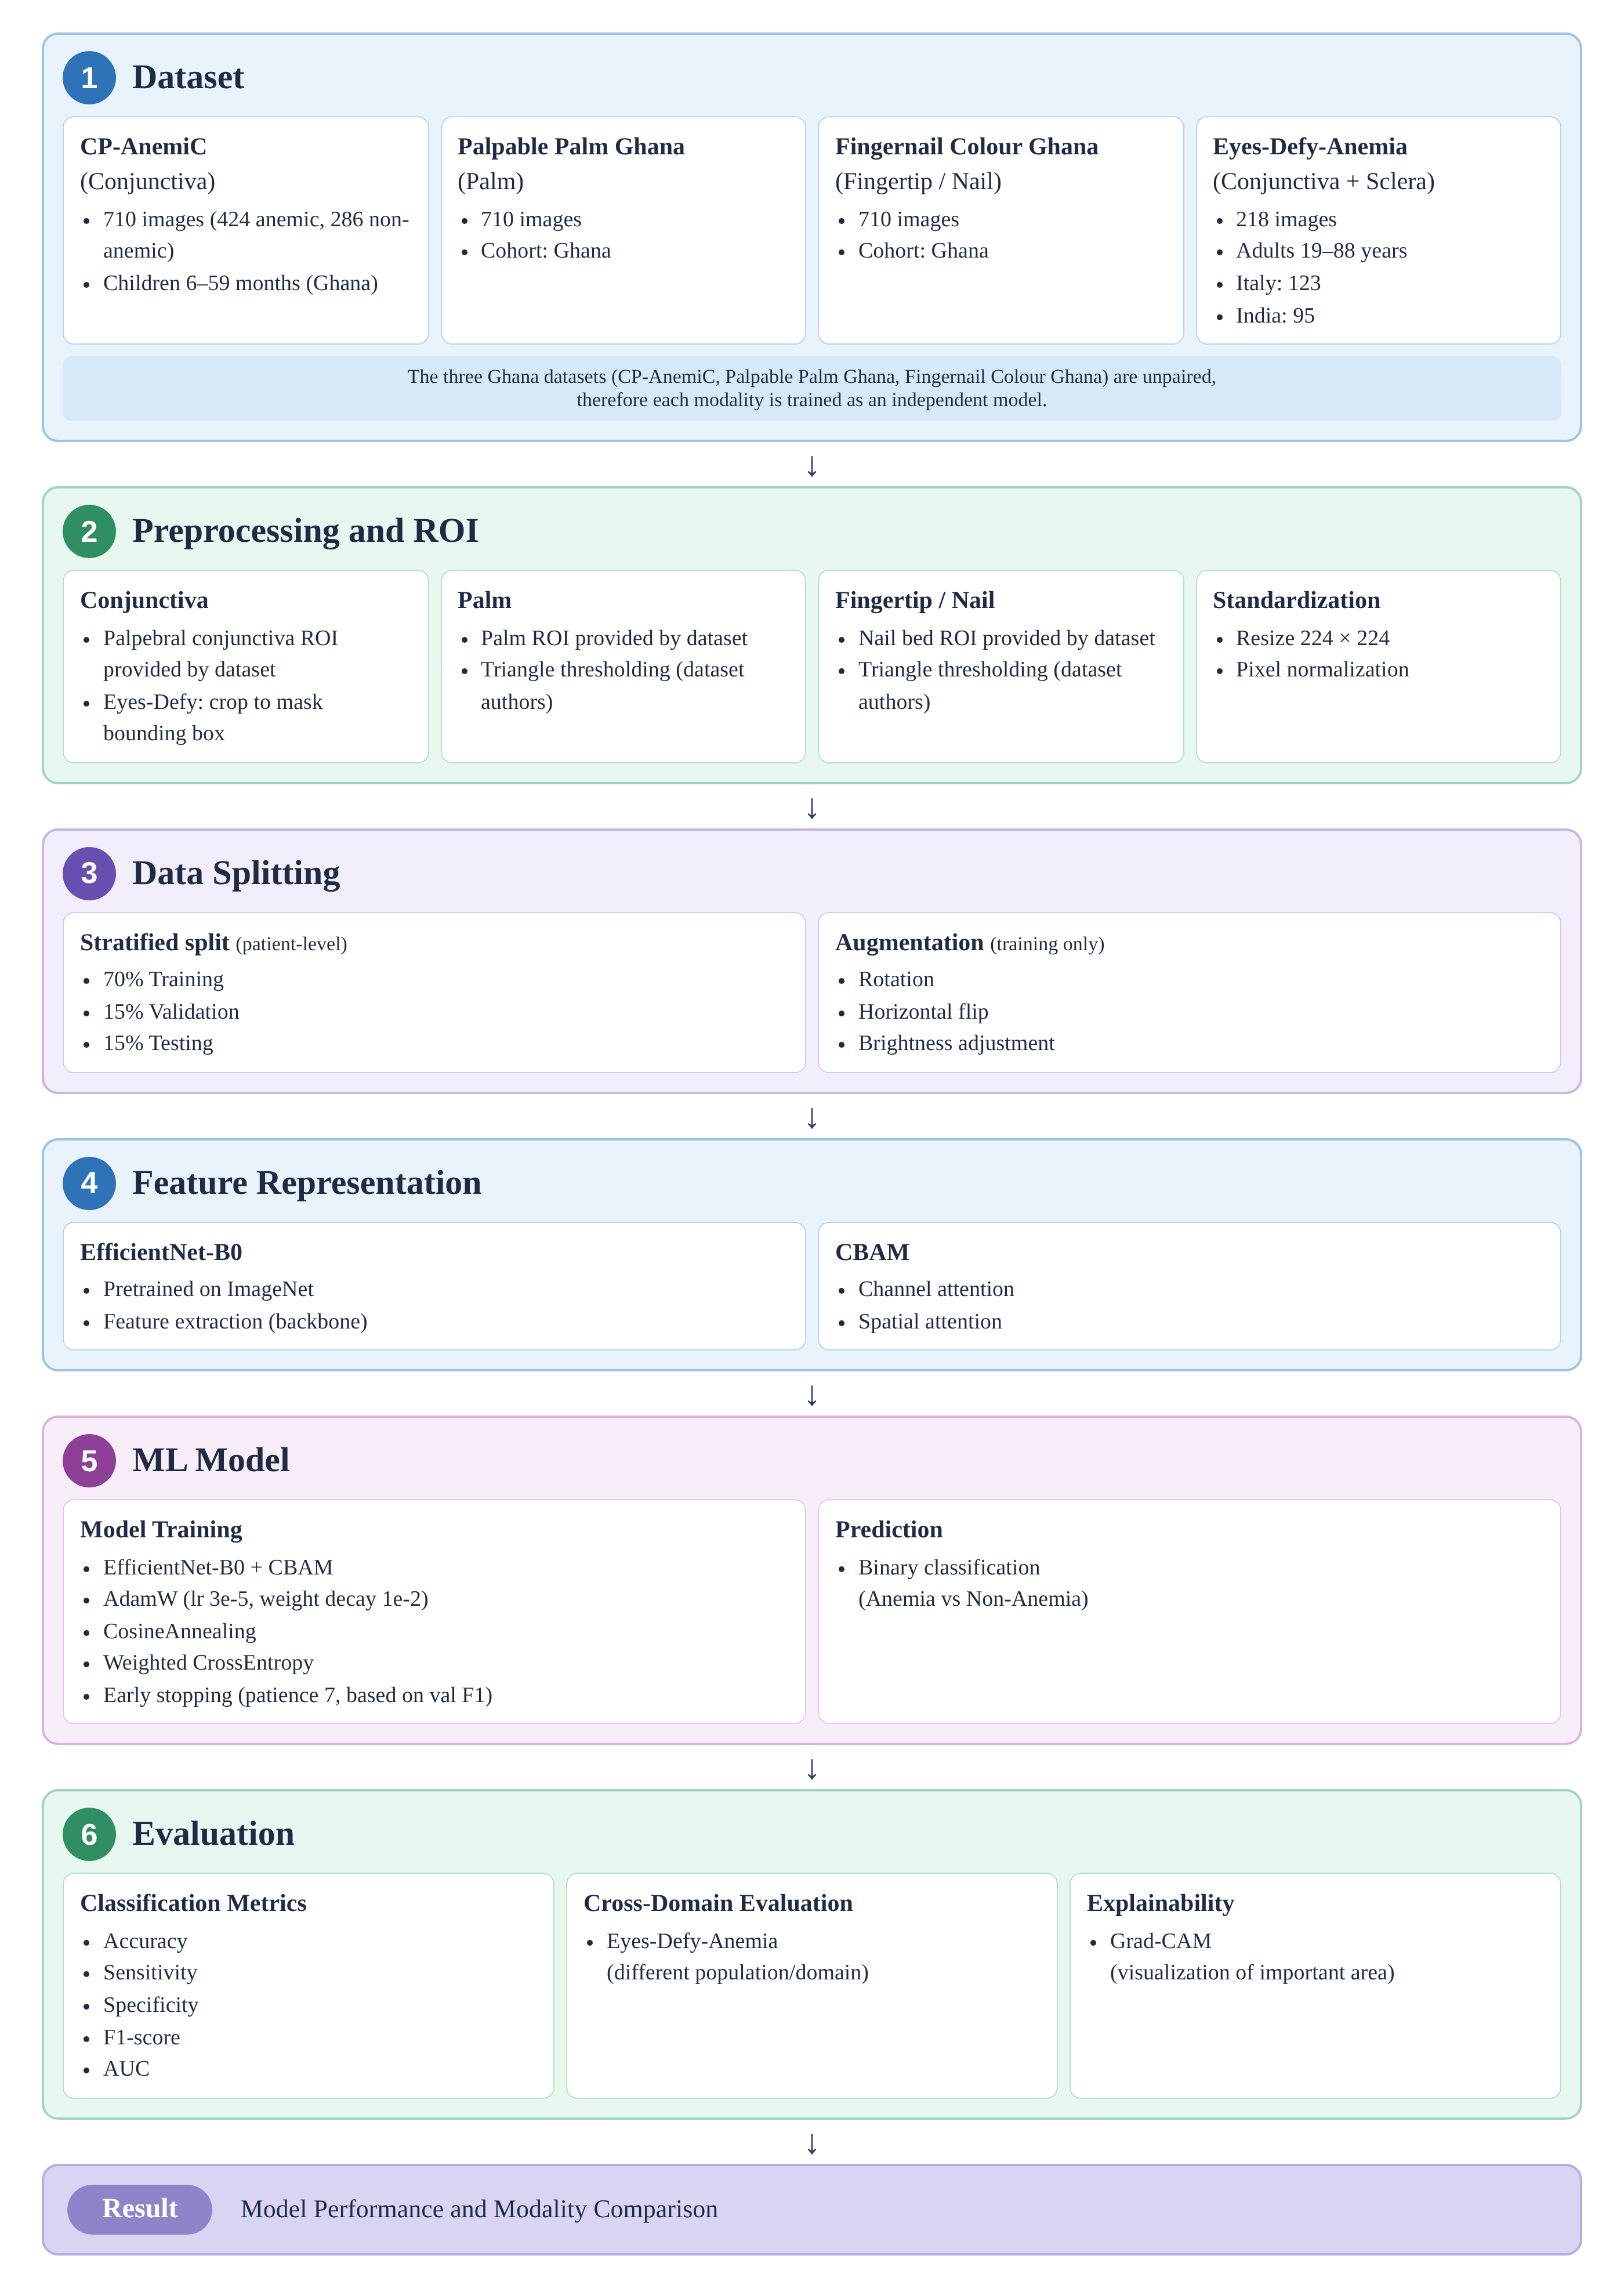

1. **Data**: 3 dataset ROI (konjungtiva gabungan, telapak tangan, kuku).
2. **Split per pasien** 70/15/15, stratifikasi label (StratifiedGroupKFold untuk palm & kuku). 66 citra Eyes-Defy disisihkan untuk uji cross-domain.
3. **Pre-processing**: crop bounding box mask (Eyes-Defy), resize 224×224, normalisasi ImageNet, augmentasi (train saja).
4. **Model**: EfficientNet-B0 pretrained ImageNet + CBAM, 1 model per modalitas.
5. **Training**: AdamW + CosineAnnealing, weighted cross-entropy, early stopping berdasarkan F1 validasi.
6. **Evaluasi**: test set (accuracy, sensitivity, specificity, F1, AUC + 95% CI bootstrap), uji cross-domain, Grad-CAM.

## 4. Pre-processing

| Tahap | Detail | Kode |
|---|---|---|
| ROI | Semua dataset sudah berupa ROI dari penyusunnya (CP-AnemiC, palm, kuku: segmentasi triangle thresholding; Eyes-Defy: mask konjungtiva palpebra). Untuk mask Eyes-Defy, latar kosong dibuang dengan crop ke bounding box. | `src/data/dataset.py` |
| Label | Hb → anemia/non-anemia sesuai batas WHO (anak < 11; perempuan < 12; laki-laki < 13 g/dL) | `src/data/prepare_metadata.py` |
| Split | 70/15/15 per pasien/subjek, stratifikasi label (+ sumber dataset untuk konjungtiva) | `src/data/create_splits.py` |
| Resize & normalisasi | 224×224, mean/std ImageNet | `src/data/transforms.py` |
| Augmentasi (train saja) | RandomResizedCrop (0,7–1,0), flip horizontal/vertikal, rotasi ±15°, brightness/contrast 0,1 (**saturasi tidak diubah** supaya warna pucat tidak rusak), RandomErasing 0,25 | `src/data/transforms.py` |

In [9]:
from src.data.transforms import get_train_transforms, get_eval_transforms, IMAGENET_MEAN, IMAGENET_STD
from src.data.dataset import get_dataset
print("Transform TRAIN:\n", get_train_transforms())
print("\nTransform VAL/TEST:\n", get_eval_transforms())

Transform TRAIN:
 Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    RandomErasing(p=0.25, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0, inplace=False)
)

Transform VAL/TEST:
 Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


Visualisasi: citra asli → setelah crop ROI (dataset) → transform val/test → 3 contoh augmentasi train.

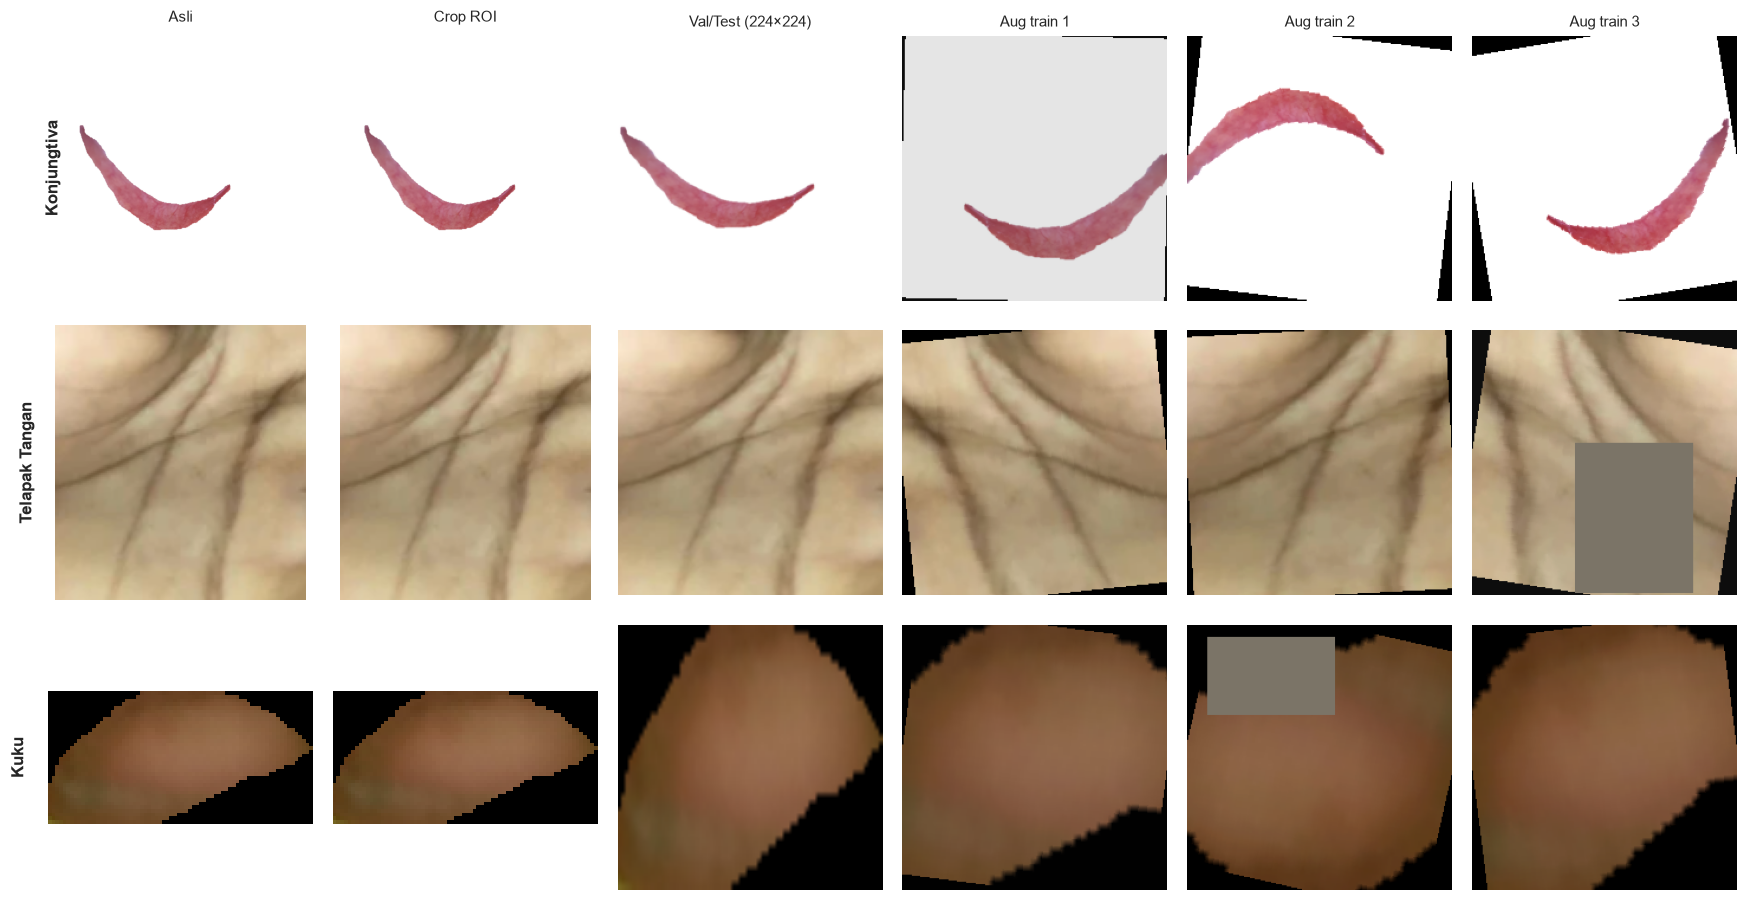

In [10]:
import torch
def ke_gambar(t):
    t = t * torch.tensor(IMAGENET_STD)[:, None, None] + torch.tensor(IMAGENET_MEAN)[:, None, None]
    return t.clamp(0, 1).permute(1, 2, 0).numpy()

torch.manual_seed(0)
contoh = {}
for m in MOD:
    ds = get_dataset(m, split="train"); ds.transform = None
    d = ds.data
    if "is_mask" in d and d["is_mask"].astype(bool).any():
        idx = int(np.flatnonzero(d["is_mask"].astype(bool))[0])   # tunjukkan efek crop mask Eyes-Defy
    else:
        idx = 0
    contoh[m] = (Image.open(d.loc[idx, "image_path"]).convert("RGB"), ds[idx][0])

kolom = ["Asli", "Crop ROI", "Val/Test (224×224)", "Aug train 1", "Aug train 2", "Aug train 3"]
fig, ax = plt.subplots(len(MOD), 6, figsize=(16, 2.8 * len(MOD)), squeeze=False)
tr, ev = get_train_transforms(), get_eval_transforms()
for r, m in enumerate(MOD):
    asli, crop = contoh[m]
    imgs = [np.asarray(asli), np.asarray(crop), ke_gambar(ev(crop))] + [ke_gambar(tr(crop)) for _ in range(3)]
    for c, im in enumerate(imgs):
        ax[r, c].imshow(im); ax[r, c].axis("off")
        if r == 0: ax[r, c].set_title(kolom[c], fontsize=10)
    ax[r, 0].text(-0.08, 0.5, MOD[m], transform=ax[r, 0].transAxes, rotation=90, va="center", ha="right", fontsize=11, fontweight="bold")
fig.tight_layout(); save(fig, "10_preprocessing")

## 5. Feature Engineering

**Tidak dilakukan feature engineering manual untuk model.** CNN (EfficientNet-B0 + CBAM) mempelajari fiturnya sendiri langsung dari piksel (*representation learning*); CBAM membantu model memilih kanal dan area citra yang relevan.

Fitur warna buatan tangan (a\* CIELAB, rasio merah, dll.) **hanya dipakai di EDA** (bagian 2.6) untuk mengecek apakah kepucatan memang terlihat secara statistik, bukan sebagai input model.

## 6. Model Development

**Arsitektur:** EfficientNet-B0 (pretrained ImageNet) → feature map 1280×7×7 → **CBAM** (channel attention + spatial attention) → Global Average Pooling → Dropout 0,3 → Linear (2 kelas). Satu model dilatih terpisah untuk tiap modalitas dengan setting yang sama.

| Hyperparameter | Nilai |
|---|---|
| Input | 224×224 RGB |
| Optimizer | AdamW, LR 3e-5, weight decay 1e-2 |
| Scheduler | CosineAnnealing |
| Loss | Cross-entropy berbobot kelas |
| Batch size | 16 |
| Epoch | maks. 40, early stopping patience 7 (pantau F1 validasi) |
| Pemilihan model | checkpoint dengan **F1 validasi** terbaik (test set tidak dipakai untuk memilih) |

In [11]:
import importlib.util
from src import config
from src.models.efficientnet_cbam import EfficientNetB0_CBAM
print({k: getattr(config, k) for k in ["IMAGE_SIZE", "BATCH_SIZE", "WEIGHT_DECAY", "NUM_EPOCHS", "EARLY_STOPPING_PATIENCE"]}, "| LR dipakai: 3e-5")
m_ = EfficientNetB0_CBAM(num_classes=2, pretrained=False)
print("\nBagian setelah backbone:")
for nama, modul in m_.named_children():
    if nama != "features": print(f"  {nama}: {modul}")

{'IMAGE_SIZE': (224, 224), 'BATCH_SIZE': 16, 'WEIGHT_DECAY': 0.01, 'NUM_EPOCHS': 40, 'EARLY_STOPPING_PATIENCE': 7} | LR dipakai: 3e-5

Bagian setelah backbone:
  cbam: CBAM(
  (channel_attention): ChannelAttention(
    (avg_pool): AdaptiveAvgPool2d(output_size=1)
    (max_pool): AdaptiveMaxPool2d(output_size=1)
    (mlp): Sequential(
      (0): Linear(in_features=1280, out_features=80, bias=False)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=80, out_features=1280, bias=False)
    )
    (sigmoid): Sigmoid()
  )
  (spatial_attention): SpatialAttention(
    (conv): Conv2d(2, 1, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (sigmoid): Sigmoid()
  )
)
  avgpool: AdaptiveAvgPool2d(output_size=1)
  classifier: Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


### 6.1 Training
Set `JALANKAN_TRAINING = True` untuk melatih ulang (±menit–jam per modalitas). Checkpoint lama akan **tertimpa**.

In [12]:
JALANKAN_TRAINING = False
LR = 3e-5

if JALANKAN_TRAINING:
    spec = importlib.util.spec_from_file_location("train", ROOT / "scripts" / "3_train_models.py")
    train = importlib.util.module_from_spec(spec); spec.loader.exec_module(train)
    for m in MOD:
        train.train_modality(m, lr=LR)
else:
    for m in MOD:
        ck = CHECKPOINTS_DIR / m / "best_model.pth"
        print(f"{MOD[m]:15s} pakai checkpoint: {ck.relative_to(ROOT)}  ({'ada' if ck.exists() else 'TIDAK ADA'})")

Konjungtiva     pakai checkpoint: checkpoints/conjunctiva/best_model.pth  (ada)
Telapak Tangan  pakai checkpoint: checkpoints/palm/best_model.pth  (ada)
Kuku            pakai checkpoint: checkpoints/fingernail/best_model.pth  (ada)


### 6.2 Profil model: jumlah parameter, ukuran, latensi

In [13]:
import torch
from src.models.efficientnet_cbam import EfficientNetB0_CBAM
model = EfficientNetB0_CBAM(num_classes=2, pretrained=False).eval()
n_param = sum(p.numel() for p in model.parameters())
buf = io.BytesIO(); torch.save(model.state_dict(), buf); size_mb = buf.tell() / 1e6

def latensi(dev, n=100):
    m = model.to(dev); x = torch.randn(1, 3, 224, 224, device=dev)
    sync = torch.mps.synchronize if dev == "mps" else (lambda: None)
    with torch.no_grad():
        for _ in range(10): m(x); sync()
        t = []
        for _ in range(n):
            s = time.perf_counter(); m(x); sync(); t.append((time.perf_counter() - s) * 1000)
    return np.median(t), np.percentile(t, 95)

profil = [{"Metrik": "Jumlah parameter", "Nilai": f"{n_param/1e6:.2f} juta"},
          {"Metrik": "Ukuran bobot (float32)", "Nilai": f"{size_mb:.1f} MB"}]
for dev in ["cpu"] + (["mps"] if torch.backends.mps.is_available() else []):
    med, p95 = latensi(dev)
    profil.append({"Metrik": f"Latensi 1 citra di {dev.upper()} (median / p95)", "Nilai": f"{med:.1f} ms / {p95:.1f} ms"})
profil = pd.DataFrame(profil); profil.to_csv(TAB / "profil_model.csv", index=False); display(profil)
print("Diukur di MacBook Air (CPU dan GPU Apple/MPS), bukan di HP.")

,Metrik,Nilai
0,Jumlah parameter,4.22 juta
1,Ukuran bobot (float32),17.2 MB
2,Latensi 1 citra di CPU (median / p95),82.4 ms / 117.6 ms
3,Latensi 1 citra di MPS (median / p95),5.6 ms / 6.6 ms


Diukur di MacBook Air (CPU dan GPU Apple/MPS), bukan di HP.


## 7. Model Evaluation
Memuat `checkpoints/<modalitas>/best_model.pth`. Interval kepercayaan 95% dihitung dengan bootstrap (1.000×) karena test set kecil, terutama konjungtiva.

In [14]:
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score
from src.data.dataset import get_dataset
dev = "mps" if torch.backends.mps.is_available() else "cpu"
rng = np.random.default_rng(42)

def ci(y, p, fn, B=1000):
    v = []
    for _ in range(B):
        i = rng.integers(0, len(y), len(y))
        if len(set(y[i])) < 2: continue
        v.append(fn(y[i], p[i]))
    return np.percentile(v, [2.5, 97.5])

hasil, per_sumber, ROC, CM = [], [], {}, {}
for m in MOD:
    ck = torch.load(CHECKPOINTS_DIR / m / "best_model.pth", map_location="cpu", weights_only=False)
    net = EfficientNetB0_CBAM(num_classes=2, pretrained=False); net.load_state_dict(ck["model_state_dict"]); net.to(dev).eval()
    dl = DataLoader(get_dataset(m, split="test"), batch_size=32, shuffle=False, num_workers=0)
    ys, ps, ids = [], [], []
    with torch.no_grad():
        for x, y, sid in dl:
            ps.append(torch.softmax(net(x.to(dev)), 1)[:, 1].cpu().numpy()); ys.append(y.numpy()); ids += list(sid)
    y, p = np.concatenate(ys), np.concatenate(ps); yh = (p >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, yh, labels=[0, 1]).ravel()
    auc_lo, auc_hi = ci(y, p, roc_auc_score)
    f1_lo, f1_hi = ci(y, p, lambda a, b: f1_score(a, (b >= 0.5).astype(int)))
    hasil.append({"Modalitas": MOD[m], "Best epoch": ck.get("epoch"), "n test": len(y),
                  "Accuracy": (tp + tn) / len(y), "Sensitivity": tp / (tp + fn), "Specificity": tn / (tn + fp),
                  "Precision": precision_score(y, yh, zero_division=0), "F1": f1_score(y, yh),
                  "F1 95% CI": f"{f1_lo:.3f}–{f1_hi:.3f}", "AUC": roc_auc_score(y, p), "AUC 95% CI": f"{auc_lo:.3f}–{auc_hi:.3f}"})
    ROC[m] = roc_curve(y, p); CM[m] = np.array([[tn, fp], [fn, tp]])
    if m == "conjunctiva":   # rincian test set gabungan per sumber
        ids = np.array([str(i) for i in ids])
        for pre, nama in [("cp_", "CP-AnemiC"), ("eyes_", "Eyes-Defy")]:
            k = np.char.startswith(ids, pre)
            if k.sum() == 0 or len(set(y[k])) < 2: continue
            yk, pk = y[k], p[k]; hk = (pk >= 0.5).astype(int)
            tn_, fp_, fn_, tp_ = confusion_matrix(yk, hk, labels=[0, 1]).ravel()
            per_sumber.append({"Modalitas": f"  ↳ Konjungtiva: subset {nama}", "n test": int(k.sum()),
                               "Accuracy": (tp_ + tn_) / k.sum(), "Sensitivity": tp_ / (tp_ + fn_), "Specificity": tn_ / (tn_ + fp_),
                               "Precision": precision_score(yk, hk, zero_division=0), "F1": f1_score(yk, hk), "AUC": roc_auc_score(yk, pk)})
hasil = pd.DataFrame(hasil + per_sumber).set_index("Modalitas").round(4)
hasil.to_csv(TAB / "hasil_perbandingan_3_modalitas.csv"); display(hasil)

,Best epoch,n test,Accuracy,Sensitivity,Specificity,Precision,F1,F1 95% CI,AUC,AUC 95% CI
Modalitas,,,,,,,,,,
Konjungtiva,25.0,130,0.7615,0.7838,0.7321,0.7945,0.7891,0.709–0.855,0.8002,0.719–0.873
Telapak Tangan,26.0,648,0.8056,0.7744,0.8527,0.8882,0.8274,0.795–0.856,0.8980,0.873–0.921
Kuku,2.0,641,0.6069,0.7584,0.3730,0.6512,0.7007,0.663–0.731,0.6603,0.622–0.704
↳ Konjungtiva: subset CP-AnemiC,NaN,107,0.7477,0.7812,0.6977,0.7937,0.7874,NaN,0.7914,NaN
↳ Konjungtiva: subset Eyes-Defy,NaN,23,0.8261,0.8000,0.8462,0.8000,0.8000,NaN,0.8385,NaN


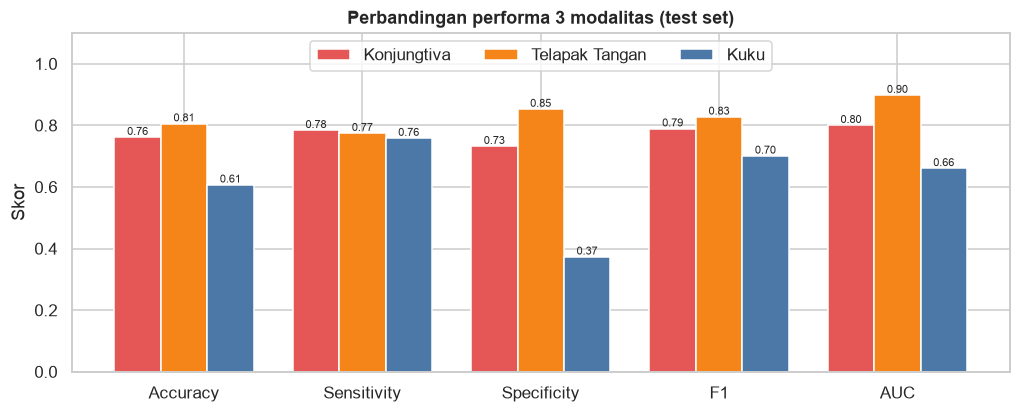

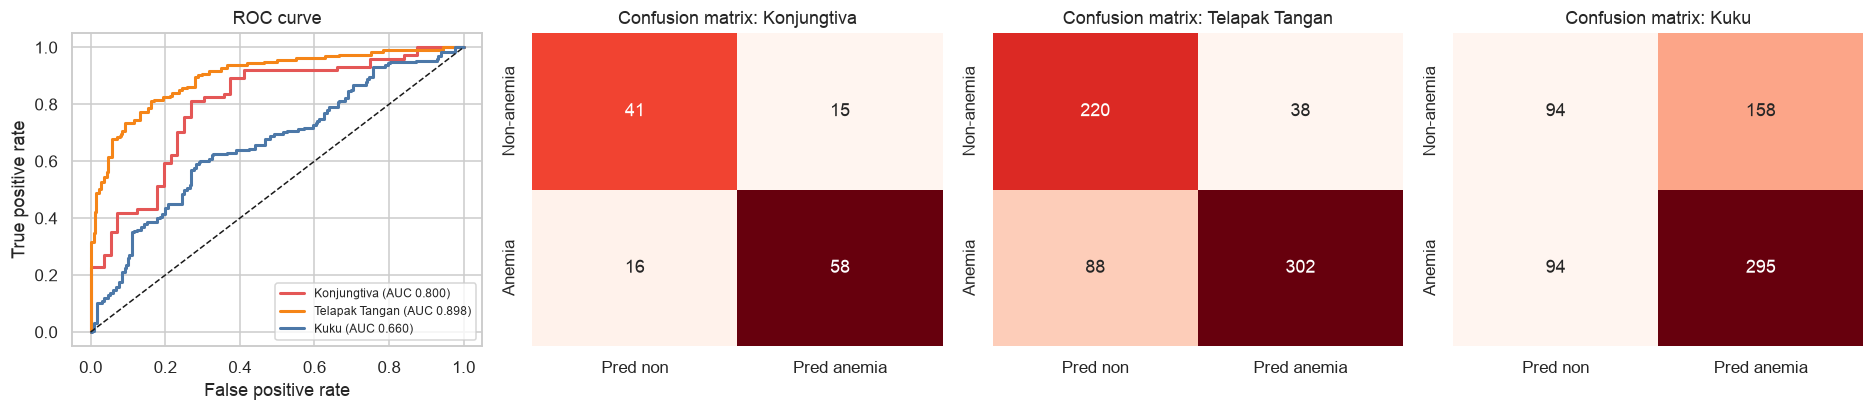

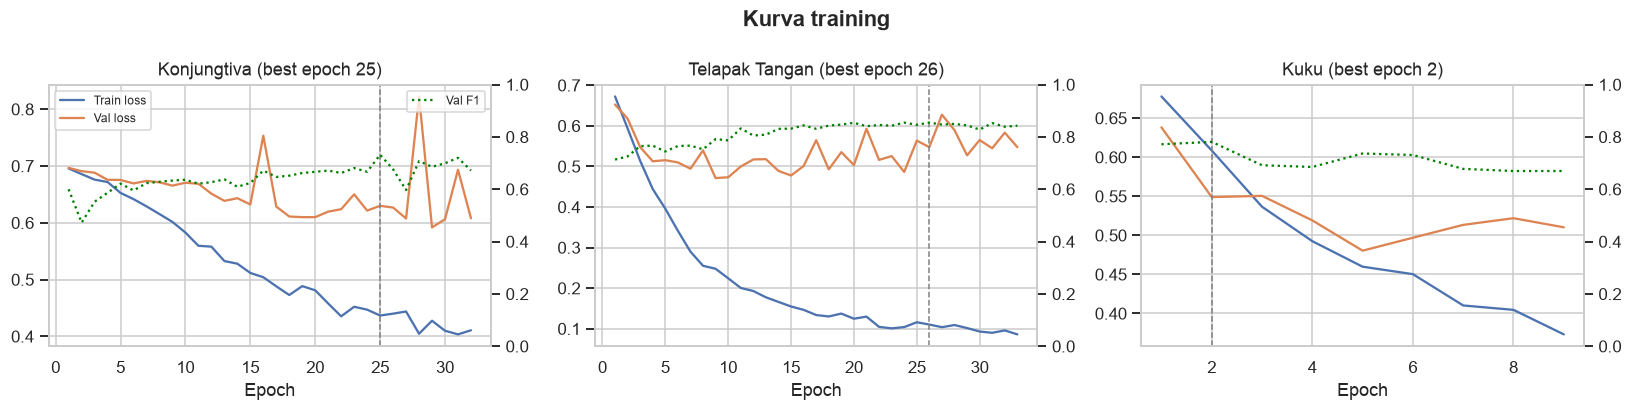

Grafik: /Users/cindypermatasarikhoeniawan/DeepLearning_Anemia/results/figures/eda
Tabel: /Users/cindypermatasarikhoeniawan/DeepLearning_Anemia/results/tables


In [15]:
METRIK = ["Accuracy", "Sensitivity", "Specificity", "F1", "AUC"]
WARNA = {"Konjungtiva": "#E45756", "Telapak Tangan": "#F58518", "Kuku": "#4C78A8"}
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(METRIK)); w = 0.26
for i, (mod, row) in enumerate(hasil.loc[list(MOD.values())].iterrows()):
    b = ax.bar(x + (i - (len(MOD) - 1) / 2) * w, row[METRIK].astype(float), w, label=mod, color=WARNA[mod])
    ax.bar_label(b, fmt="%.2f", fontsize=7)
ax.set_xticks(x, METRIK); ax.set_ylim(0, 1.1); ax.legend(ncol=3, loc="upper center"); ax.set_ylabel("Skor")
ax.set_title("Perbandingan performa 3 modalitas (test set)", fontweight="bold"); save(fig, "07_perbandingan_metrik")

fig, ax = plt.subplots(1, len(MOD) + 1, figsize=(4.3 * (len(MOD) + 1), 3.9))
for m, (fpr, tpr, _) in ROC.items():
    ax[0].plot(fpr, tpr, color=WARNA[MOD[m]], lw=2, label=f"{MOD[m]} (AUC {hasil.loc[MOD[m], 'AUC']:.3f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=1); ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate")
ax[0].set_title("ROC curve"); ax[0].legend(fontsize=8, loc="lower right")
for a, m in zip(ax[1:], MOD):
    sns.heatmap(CM[m], annot=True, fmt="d", cmap="Reds", cbar=False, ax=a,
                xticklabels=["Pred non", "Pred anemia"], yticklabels=["Non-anemia", "Anemia"])
    a.set_title(f"Confusion matrix: {MOD[m]}")
fig.tight_layout(); save(fig, "08_roc_confusion")

fig, ax = plt.subplots(1, len(MOD), figsize=(5 * len(MOD), 3.8), squeeze=False); ax = ax[0]
for a, m in zip(ax, MOD):
    h = pd.read_csv(LOGS_DIR / f"{m}_training_history.csv")
    a.plot(h.epoch, h.train_loss, label="Train loss"); a.plot(h.epoch, h.val_loss, label="Val loss")
    a2 = a.twinx(); a2.plot(h.epoch, h.val_f1, color="green", ls=":", label="Val F1"); a2.set_ylim(0, 1); a2.grid(False)
    best = h.loc[h.val_f1.idxmax(), "epoch"]; a.axvline(best, color="grey", ls="--", lw=1)
    a.set_title(f"{MOD[m]} (best epoch {best})"); a.set_xlabel("Epoch")
    if a is ax[0]: a.legend(loc="upper left", fontsize=8); a2.legend(loc="upper right", fontsize=8)
fig.suptitle("Kurva training", fontweight="bold"); fig.tight_layout(); save(fig, "09_kurva_training")
print("Grafik:", FIG); print("Tabel:", TAB)

### 7.1 Uji cross-domain konjungtiva
Model konjungtiva diuji pada 66 citra Eyes-Defy yang **tidak pernah** dipakai saat training/validasi.

In [16]:
cd = pd.read_csv(TAB / "conjunctiva_internal_vs_crossdomain.csv").set_index("evaluation")
display(cd[["accuracy", "sensitivity", "specificity", "f1_score", "roc_auc"]].round(3))

,accuracy,sensitivity,specificity,f1_score,roc_auc
evaluation,,,,,
internal_test,0.762,0.784,0.732,0.789,0.80
crossdomain_external_test,0.727,0.607,0.816,0.654,0.81


### 7.2 Grad-CAM: area yang dilihat model

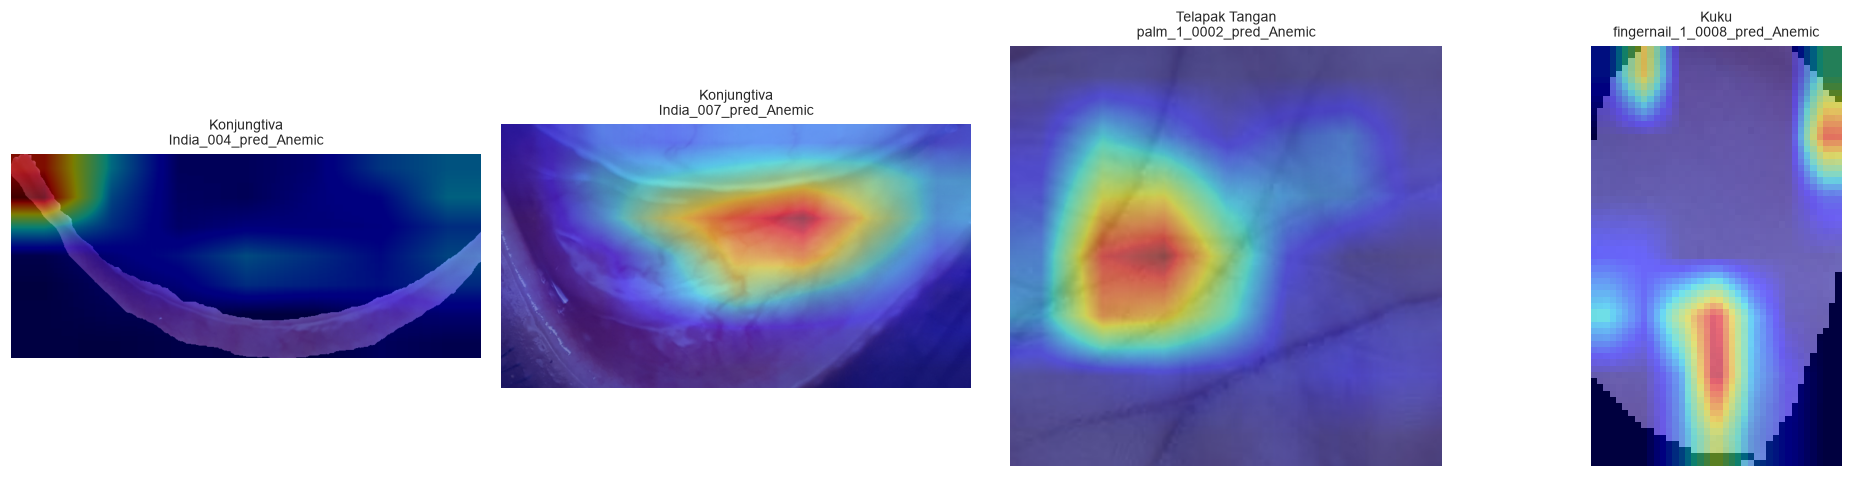

In [17]:
GC = ROOT / "results" / "figures" / "gradcam"
gambar = [(MOD.get(m, m), p) for m in MOD for p in sorted((GC / m).glob("*.png"))[:2]]
if not gambar:
    print("Belum ada gambar Grad-CAM di", GC)
else:
    fig, ax = plt.subplots(1, len(gambar), figsize=(4.5 * len(gambar), 4.5), squeeze=False)
    for a, (nama, p) in zip(ax[0], gambar):
        a.imshow(Image.open(p)); a.axis("off"); a.set_title(f"{nama}\n{p.stem}", fontsize=9)
    fig.tight_layout(); plt.show()

## Kesimpulan

- **Telapak tangan** memberi performa terbaik (F1 0,827; AUC 0,898), disusul **konjungtiva** (F1 0,789; AUC 0,800). **Kuku** paling lemah (AUC 0,660; specificity 0,373): model cenderung menebak "anemia".
- Pada uji **cross-domain** (66 citra Eyes-Defy yang tidak dilihat saat training), AUC konjungtiva tetap ≈0,81, tetapi sensitivity turun ke 0,607 (F1 0,654): model masih bisa membedakan kelas, namun threshold 0,5 kurang pas untuk domain baru.
- Model ringan (≈4,2 juta parameter, ≈17 MB), sehingga layak untuk skrining di perangkat sederhana.

**Keterbatasan:** test set konjungtiva kecil (n = 130, CI lebar); palm & kuku berasal dari 710 foto asli sehingga variasi pasien terbatas; belum ada validasi silang k-fold.

**Rencana lanjutan (masukan dosen):** k-fold cross-validation + cross-prediction, pembanding algoritma lain (mis. SVM/Random Forest/XGBoost pada fitur CNN), multimodal, dan stacking/modifikasi arsitektur.